In [ ]:
# Cell 1 - Install libraries
!pip install tensorflow matplotlib numpy pillow -q
# Cell 1 - Install libraries
!pip install torch torchvision matplotlib -q
print("Done")

Done


In [ ]:
# Cell 2 - Download Food101 dataset
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

print("Downloading Food101 dataset (subset)...")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = torchvision.datasets.Food101(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.Food101(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

print(f"Total classes: {len(train_dataset.classes)}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Sample classes: {train_dataset.classes[:5]}")

100%|██████████| 5.00G/5.00G [03:32<00:00, 23.5MB/s]


Total classes: 101
Train samples: 75750
Test samples: 25250
Sample classes: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']


In [ ]:
import torch
from torch.utils.data import DataLoader, Subset
import numpy as np

# Select only 10 food classes
SELECTED_CLASSES = [
    'pizza', 'sushi', 'burger', 'ice_cream', 'biryani',
    'samosa', 'pasta', 'fried_rice', 'donuts', 'omelette'
]

# Filter to only available classes
available = train_dataset.classes
SELECTED_CLASSES = [c for c in SELECTED_CLASSES if c in available]

# Fallback: just pick first 10 if above not found
if len(SELECTED_CLASSES) < 5:
    SELECTED_CLASSES = train_dataset.classes[:10]

print(f"Using classes: {SELECTED_CLASSES}")

# Get class indices
class_to_idx = train_dataset.class_to_idx
selected_indices = {cls: class_to_idx[cls] for cls in SELECTED_CLASSES}
selected_idx_values = list(selected_indices.values())

# Filter train dataset
train_targets = np.array(train_dataset._labels)
train_mask = np.isin(train_targets, selected_idx_values)
train_subset = Subset(train_dataset, np.where(train_mask)[0])

# Filter test dataset
test_targets = np.array(test_dataset._labels)
test_mask = np.isin(test_targets, selected_idx_values)
test_subset = Subset(test_dataset, np.where(test_mask)[0])

print(f"Train subset size: {len(train_subset)}")
print(f"Test subset size: {len(test_subset)}")

# DataLoaders
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False, num_workers=2)

print("DataLoaders ready.")

Using classes: ['pizza', 'sushi', 'ice_cream', 'samosa', 'fried_rice', 'donuts', 'omelette']
Train subset size: 5250
Test subset size: 1750
DataLoaders ready.


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = len(SELECTED_CLASSES)

print(f"Device: {DEVICE}")
print(f"Number of classes: {NUM_CLASSES}")

# Load pretrained MobileNetV2
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# Freeze all base layers
for param in model.parameters():
    param.requires_grad = False

# Replace final classifier with our own
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.last_channel, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, NUM_CLASSES)
)

model = model.to(DEVICE)

# Only train the classifier head
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

print(f"\nModel ready. Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("Base layers frozen. Only classifier head will be trained.")

Device: cuda
Number of classes: 7
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 50.5MB/s]



Model ready. Trainable params: 329,735
Base layers frozen. Only classifier head will be trained.


In [ ]:
# Training loop
EPOCHS = 10

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        # Remap labels to 0-based index for our subset
        remapped = torch.tensor([selected_idx_values.index(l.item()) for l in labels])
        images, remapped = images.to(DEVICE), remapped.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, remapped)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(remapped).sum().item()
        total += remapped.size(0)

    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            remapped = torch.tensor([selected_idx_values.index(l.item()) for l in labels])
            images, remapped = images.to(DEVICE), remapped.to(DEVICE)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(remapped).sum().item()
            total += remapped.size(0)
    return 100. * correct / total


print(f"Training for {EPOCHS} epochs on {DEVICE}...\n")
best_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    test_acc = evaluate(model, test_loader)
    scheduler.step()

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "best_food_classifier.pth")

print(f"\nBest Test Accuracy: {best_acc:.2f}%")
print("Model saved as best_food_classifier.pth")

Training for 10 epochs on cuda...

Epoch [01/10] | Loss: 0.9453 | Train Acc: 69.56% | Test Acc: 84.17%
Epoch [02/10] | Loss: 0.6464 | Train Acc: 78.63% | Test Acc: 87.54%
Epoch [03/10] | Loss: 0.5457 | Train Acc: 81.89% | Test Acc: 87.54%
Epoch [04/10] | Loss: 0.4988 | Train Acc: 83.60% | Test Acc: 88.74%
Epoch [05/10] | Loss: 0.4809 | Train Acc: 84.00% | Test Acc: 88.74%
Epoch [06/10] | Loss: 0.4567 | Train Acc: 84.63% | Test Acc: 88.57%
Epoch [07/10] | Loss: 0.4297 | Train Acc: 85.50% | Test Acc: 88.69%
Epoch [08/10] | Loss: 0.4251 | Train Acc: 85.52% | Test Acc: 88.46%
Epoch [09/10] | Loss: 0.3980 | Train Acc: 86.38% | Test Acc: 88.23%
Epoch [10/10] | Loss: 0.3911 | Train Acc: 86.93% | Test Acc: 88.46%

Best Test Accuracy: 88.74%
Model saved as best_food_classifier.pth


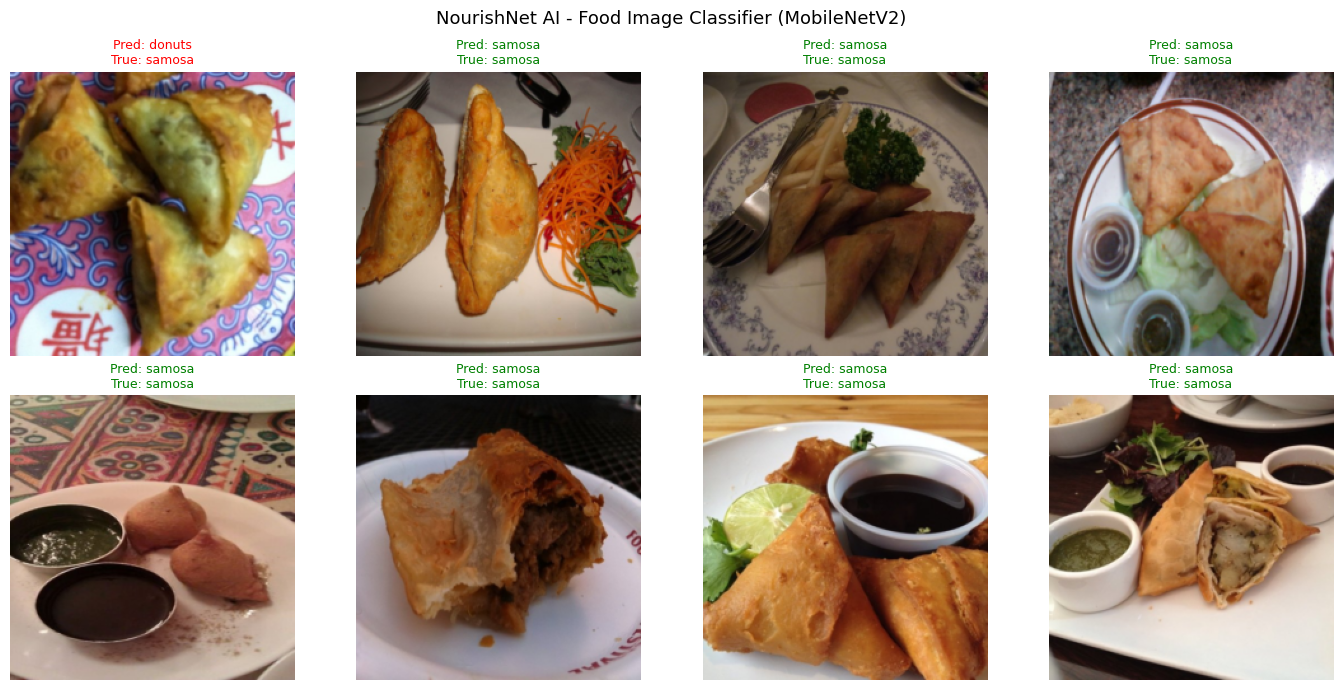

Saved: food_classifier_predictions.png


In [ ]:
import matplotlib.pyplot as plt

CLASS_NAMES = SELECTED_CLASSES

def show_predictions(model, loader, n=8):
    model.eval()
    images_shown, preds_shown, labels_shown = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            remapped = torch.tensor([selected_idx_values.index(l.item()) for l in labels])
            outputs = model(images.to(DEVICE))
            _, predicted = outputs.max(1)

            for i in range(len(images)):
                if len(images_shown) >= n:
                    break
                images_shown.append(images[i])
                preds_shown.append(predicted[i].item())
                labels_shown.append(remapped[i].item())
            if len(images_shown) >= n:
                break

    # Denormalize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for i, ax in enumerate(axes.flatten()):
        img = images_shown[i] * std + mean
        img = img.permute(1, 2, 0).numpy().clip(0, 1)
        ax.imshow(img)
        pred = CLASS_NAMES[preds_shown[i]]
        true = CLASS_NAMES[labels_shown[i]]
        color = "green" if pred == true else "red"
        ax.set_title(f"Pred: {pred}\nTrue: {true}", color=color, fontsize=9)
        ax.axis("off")

    plt.suptitle("NourishNet AI - Food Image Classifier (MobileNetV2)", fontsize=13)
    plt.tight_layout()
    plt.savefig("food_classifier_predictions.png", dpi=150)
    plt.show()
    print("Saved: food_classifier_predictions.png")

show_predictions(model, test_loader)

In [ ]:
from google.colab import files

# Download the saved model
files.download("best_food_classifier.pth")
files.download("food_classifier_predictions.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>